🧬 BIOTWIN — BIOLOGICAL SIMILARITY SEARCH ENGINE

[1/7] Creating biological expression dataset...
Samples: 600
Genes:   300

[2/7] Normalizing gene-expression data...

[3/7] Building neural biological encoder...

[4/7] Training biological representation model...
Epoch 020/100 | Reconstruction Loss: 0.23319
Epoch 040/100 | Reconstruction Loss: 0.22589
Epoch 060/100 | Reconstruction Loss: 0.21833
Epoch 080/100 | Reconstruction Loss: 0.21157
Epoch 100/100 | Reconstruction Loss: 0.20035

[5/7] Generating biological embeddings...
Embedding shape: (600, 16)

[6/7] Building biological similarity engine...

[7/7] Creating biological universe...

BIOLOGICAL TWIN SEARCH

Query sample: SAMPLE_0001
Biological state: Stress

Closest biological twins:

  sample_id biological_state similarity similarity_percent
SAMPLE_0010          Cycling     0.9880             98.80%
SAMPLE_0408          Cycling     0.9721             97.21%
SAMPLE_0359           Stress     0.9586             95.86%
SAMPLE_0343     

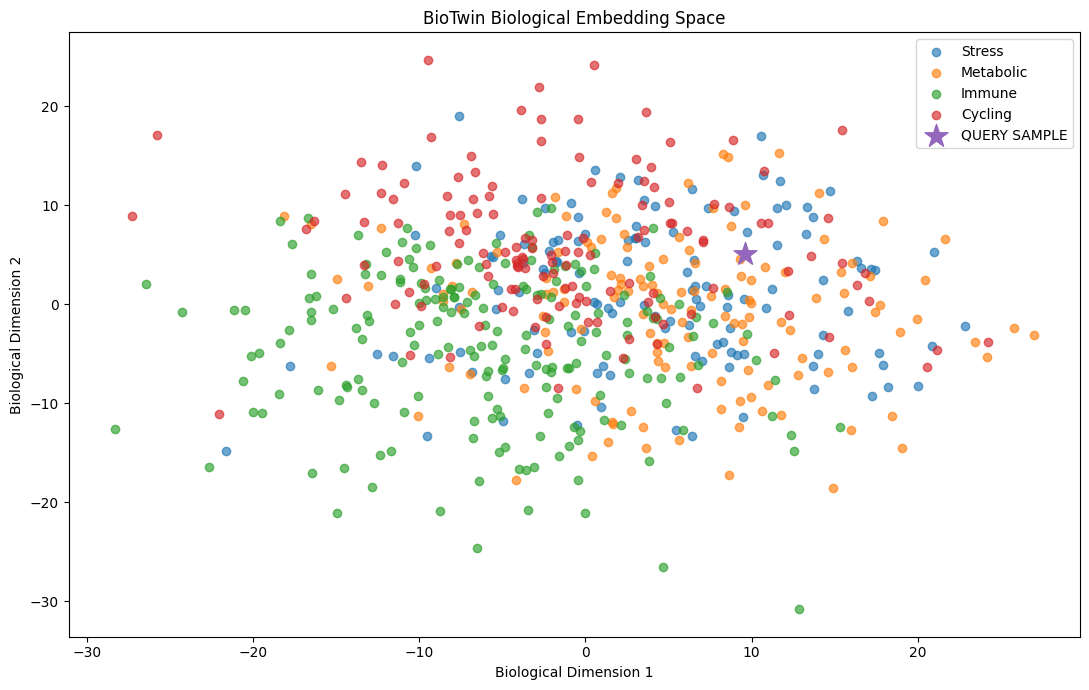


Files created:
  biotwin_embeddings.csv
  biotwin_metadata.csv

Example API search:
  sample_id biological_state  similarity  similarity_percent
SAMPLE_0010          Cycling    0.987993           98.799347
SAMPLE_0408          Cycling    0.972094           97.209351
SAMPLE_0359           Stress    0.958573           95.857338
SAMPLE_0343          Cycling    0.948729           94.872849
SAMPLE_0442          Cycling    0.934054           93.405441

BIOTWIN PIPELINE COMPLETE

Pipeline:

Gene Expression
      ↓
Normalization
      ↓
Neural Autoencoder
      ↓
Biological Embedding
      ↓
Cosine Similarity
      ↓
Biological Twins
      ↓
Biological Program Explanation
      ↓
Interactive Biological Map

IMPORTANT:
This prototype uses simulated data.
For a real bioinformatics project, replace the
synthetic expression matrix with a properly processed
CELLxGENE/GEO dataset and preserve the biological
metadata and experimental design.



In [1]:
# ============================================================
# BIOTWIN — AI-POWERED BIOLOGICAL SIMILARITY SEARCH ENGINE
# Complete prototype in ONE CELL
# ============================================================

# If running in a fresh notebook, uncomment:
# !pip install numpy pandas scikit-learn matplotlib seaborn torch plotly streamlit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 600
N_GENES = 300
LATENT_DIM = 16
EPOCHS = 100
BATCH_SIZE = 64

print("=" * 70)
print("🧬 BIOTWIN — BIOLOGICAL SIMILARITY SEARCH ENGINE")
print("=" * 70)

# ============================================================
# 2. CREATE A BIOLOGICALLY INSPIRED DEMO DATASET
# ============================================================
# This prototype uses simulated expression data so it runs
# immediately. Replace X with real CELLxGENE/GEO expression
# data later.

print("\n[1/7] Creating biological expression dataset...")

# Biological programs / latent factors
immune_program = np.random.normal(0, 1, N_SAMPLES)
metabolic_program = np.random.normal(0, 1, N_SAMPLES)
stress_program = np.random.normal(0, 1, N_SAMPLES)
cell_cycle_program = np.random.normal(0, 1, N_SAMPLES)
inflammation_program = np.random.normal(0, 1, N_SAMPLES)

X = np.random.normal(
    0,
    0.35,
    size=(N_SAMPLES, N_GENES)
)

# Gene modules
immune_genes = np.arange(0, 50)
metabolic_genes = np.arange(50, 100)
stress_genes = np.arange(100, 150)
cell_cycle_genes = np.arange(150, 200)
inflammation_genes = np.arange(200, 250)

X[:, immune_genes] += immune_program[:, None] * 1.5
X[:, metabolic_genes] += metabolic_program[:, None] * 1.3
X[:, stress_genes] += stress_program[:, None] * 1.1
X[:, cell_cycle_genes] += cell_cycle_program[:, None] * 1.2
X[:, inflammation_genes] += inflammation_program[:, None] * 1.4

# Add hidden biological states
states = np.random.choice(
    ["Immune", "Metabolic", "Stress", "Cycling"],
    size=N_SAMPLES,
    p=[0.30, 0.25, 0.20, 0.25]
)

for i, state in enumerate(states):
    if state == "Immune":
        X[i, 0:50] += 1.5
        X[i, 200:250] += 0.7

    elif state == "Metabolic":
        X[i, 50:100] += 1.7

    elif state == "Stress":
        X[i, 100:150] += 1.8

    elif state == "Cycling":
        X[i, 150:200] += 1.7

gene_names = [f"GENE_{i+1:03d}" for i in range(N_GENES)]

metadata = pd.DataFrame({
    "sample_id": [f"SAMPLE_{i+1:04d}" for i in range(N_SAMPLES)],
    "biological_state": states
})

print(f"Samples: {N_SAMPLES}")
print(f"Genes:   {N_GENES}")

# ============================================================
# 3. NORMALIZE EXPRESSION DATA
# ============================================================

print("\n[2/7] Normalizing gene-expression data...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

# ============================================================
# 4. BUILD AUTOENCODER
# ============================================================

print("\n[3/7] Building neural biological encoder...")

class BioTwinAutoencoder(nn.Module):

    def __init__(self, input_dim, latent_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        reconstruction = self.decoder(z)

        return reconstruction, z


model = BioTwinAutoencoder(
    input_dim=N_GENES,
    latent_dim=LATENT_DIM
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.MSELoss()

# ============================================================
# 5. TRAIN MODEL
# ============================================================

print("\n[4/7] Training biological representation model...")

model.train()

for epoch in range(EPOCHS):

    permutation = torch.randperm(
        X_tensor.size(0)
    )

    total_loss = 0

    for i in range(
        0,
        X_tensor.size(0),
        BATCH_SIZE
    ):

        indices = permutation[
            i:i+BATCH_SIZE
        ]

        batch = X_tensor[indices]

        optimizer.zero_grad()

        reconstructed, latent = model(batch)

        loss = criterion(
            reconstructed,
            batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:

        avg_loss = (
            total_loss /
            max(1, X_tensor.size(0) // BATCH_SIZE)
        )

        print(
            f"Epoch {epoch+1:03d}/{EPOCHS} "
            f"| Reconstruction Loss: {avg_loss:.5f}"
        )

# ============================================================
# 6. GENERATE BIOLOGICAL EMBEDDINGS
# ============================================================

print("\n[5/7] Generating biological embeddings...")

model.eval()

with torch.no_grad():

    reconstructed, embeddings = model(
        X_tensor
    )

embeddings = embeddings.numpy()

print(
    "Embedding shape:",
    embeddings.shape
)

# ============================================================
# 7. BIOLOGICAL SIMILARITY ENGINE
# ============================================================

print("\n[6/7] Building biological similarity engine...")

similarity_matrix = cosine_similarity(
    embeddings
)

def find_biological_twins(
    sample_index,
    top_k=5
):

    similarities = similarity_matrix[
        sample_index
    ].copy()

    # Don't return the sample itself
    similarities[sample_index] = -1

    nearest = np.argsort(
        similarities
    )[::-1][:top_k]

    results = metadata.iloc[
        nearest
    ].copy()

    results["similarity"] = [
        similarities[i]
        for i in nearest
    ]

    results["similarity_percent"] = (
        results["similarity"] * 100
    )

    return results[
        [
            "sample_id",
            "biological_state",
            "similarity",
            "similarity_percent"
        ]
    ].reset_index(drop=True)


# ============================================================
# 8. CREATE 2D BIOLOGICAL MAP
# ============================================================

print("\n[7/7] Creating biological universe...")

pca = PCA(
    n_components=2,
    random_state=SEED
)

embedding_2d = pca.fit_transform(
    embeddings
)

map_df = metadata.copy()

map_df["PC1"] = embedding_2d[:, 0]
map_df["PC2"] = embedding_2d[:, 1]

# ============================================================
# 9. SHOW SAMPLE SEARCH
# ============================================================

QUERY_INDEX = 0

print("\n" + "=" * 70)
print("BIOLOGICAL TWIN SEARCH")
print("=" * 70)

print(
    "\nQuery sample:",
    metadata.iloc[QUERY_INDEX]["sample_id"]
)

print(
    "Biological state:",
    metadata.iloc[QUERY_INDEX]["biological_state"]
)

twins = find_biological_twins(
    QUERY_INDEX,
    top_k=10
)

print("\nClosest biological twins:\n")

print(
    twins.to_string(
        index=False,
        formatters={
            "similarity": "{:.4f}".format,
            "similarity_percent": "{:.2f}%".format
        }
    )
)

# ============================================================
# 10. BIOLOGICAL PROGRAM EXPLANATION
# ============================================================

def explain_sample(sample_index):

    expression = X_scaled[
        sample_index
    ]

    module_scores = {

        "Immune activity":
            np.mean(expression[0:50]),

        "Metabolic activity":
            np.mean(expression[50:100]),

        "Stress response":
            np.mean(expression[100:150]),

        "Cell-cycle activity":
            np.mean(expression[150:200]),

        "Inflammatory activity":
            np.mean(expression[200:250])
    }

    result = pd.DataFrame(
        module_scores.items(),
        columns=[
            "Biological Program",
            "Activity"
        ]
    )

    result["Activity"] = (
        result["Activity"]
        .round(3)
    )

    return result.sort_values(
        "Activity",
        ascending=False
    ).reset_index(drop=True)


print("\n" + "=" * 70)
print("BIOLOGICAL PROFILE OF QUERY")
print("=" * 70)

print(
    explain_sample(
        QUERY_INDEX
    ).to_string(index=False)
)

# ============================================================
# 11. TOP GENES CONTRIBUTING TO SAMPLE PROFILE
# ============================================================

def top_genes(
    sample_index,
    n=15
):

    expression = X_scaled[
        sample_index
    ]

    indices = np.argsort(
        np.abs(expression)
    )[::-1][:n]

    result = pd.DataFrame({

        "Gene":
            [gene_names[i] for i in indices],

        "Expression":
            [expression[i] for i in indices]
    })

    result["Absolute Signal"] = (
        np.abs(result["Expression"])
        .round(3)
    )

    result["Expression"] = (
        result["Expression"]
        .round(3)
    )

    return result


print("\nTop genes in query sample:\n")

print(
    top_genes(
        QUERY_INDEX
    ).to_string(index=False)
)

# ============================================================
# 12. PLOT BIOLOGICAL UNIVERSE
# ============================================================

fig = px.scatter(
    map_df,
    x="PC1",
    y="PC2",
    color="biological_state",
    hover_data=[
        "sample_id",
        "biological_state"
    ],
    title="BioTwin — Biological Universe",
    width=1000,
    height=700
)

fig.update_traces(
    marker=dict(
        size=8
    )
)

fig.show()

# ============================================================
# 13. STATIC MATPLOTLIB VERSION
# ============================================================

plt.figure(
    figsize=(11, 7)
)

for state in map_df[
    "biological_state"
].unique():

    subset = map_df[
        map_df["biological_state"] == state
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=state,
        alpha=0.65
    )

# Highlight query
plt.scatter(
    map_df.iloc[QUERY_INDEX]["PC1"],
    map_df.iloc[QUERY_INDEX]["PC2"],
    marker="*",
    s=300,
    label="QUERY SAMPLE"
)

plt.title(
    "BioTwin Biological Embedding Space"
)

plt.xlabel("Biological Dimension 1")
plt.ylabel("Biological Dimension 2")

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# 14. SAVE EMBEDDINGS
# ============================================================

embedding_df = pd.DataFrame(
    embeddings,
    columns=[
        f"embedding_{i+1}"
        for i in range(LATENT_DIM)
    ]
)

embedding_df.insert(
    0,
    "sample_id",
    metadata["sample_id"]
)

embedding_df["biological_state"] = (
    metadata["biological_state"]
)

embedding_df.to_csv(
    "biotwin_embeddings.csv",
    index=False
)

metadata.to_csv(
    "biotwin_metadata.csv",
    index=False
)

print("\nFiles created:")
print("  biotwin_embeddings.csv")
print("  biotwin_metadata.csv")

# ============================================================
# 15. SIMPLE API-LIKE SEARCH FUNCTION
# ============================================================

def BioTwinSearch(
    sample_id,
    top_k=5
):

    matches = metadata.index[
        metadata["sample_id"] == sample_id
    ].tolist()

    if not matches:
        return (
            f"Sample '{sample_id}' "
            "not found."
        )

    idx = matches[0]

    result = find_biological_twins(
        idx,
        top_k
    )

    return result


# Example:
print("\nExample API search:")
print(
    BioTwinSearch(
        "SAMPLE_0001",
        top_k=5
    ).to_string(index=False)
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BIOTWIN PIPELINE COMPLETE")
print("=" * 70)

print("""
Pipeline:

Gene Expression
      ↓
Normalization
      ↓
Neural Autoencoder
      ↓
Biological Embedding
      ↓
Cosine Similarity
      ↓
Biological Twins
      ↓
Biological Program Explanation
      ↓
Interactive Biological Map

IMPORTANT:
This prototype uses simulated data.
For a real bioinformatics project, replace the
synthetic expression matrix with a properly processed
CELLxGENE/GEO dataset and preserve the biological
metadata and experimental design.
""")